# Resolutor SMT con PhaseAND/PhaseOR

Este *notebook* implementa una arquitectura cuántica escalable de múltiples registros para resolver problemas de teoría de satisfacibilidad módulo (SMT) utilizando el **algoritmo de Grover**. 

## Importación de Librerías
Importamos las clases fundamentales de Qiskit para la construcción, transpilación y simulación del circuito cuántico, junto con las herramientas gráficas (`matplotlib`, `seaborn`).

Assimismo, importamos las funciones pertenecientes a la carpeta `src` que importan los distintos componentes del algoritmo de Grover, los oráculos y las abstracciones lógicas.

In [9]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

from pathlib import Path # Used for storing results
import matplotlib.pyplot as plt
import seaborn as sns

from src import (
    oracle_less, oracle_eq, oracle_greatereq, oracle_interval,
    PhaseAND, PhaseNAND, PhaseOR, PhaseNOR,
    diffuser, init
)


## Iteración de Grover

Esta función engloba todas las piezas anteriores para construir una iteración completa del algoritmo de Grover resolviendo nuestra fórmula modularmente:

1. **Computación de Oráculos**: Anexamos los oráculos matemáticos para que evalúen las restricciones independientes en cada registro. Paso posterior a la inicialización de los registros, que consideraremos independiente a la iteración.
2. **Evaluación Lógica**: Aplicamos nuestra abstracción `PhaseAND` o `PhaseOR` para forzar la fase negativa a la combinación booleana objetivo. Utilizar `PhaseNOR` frente a `PhaseOR` procede simplemente porque requiere menor profundida y actúan de forma equivalente en el caso del algoritmo de Grover.
3. **Descomputación**: Aplicamos nuevamente los oráculos. Al ser operadores hermíticos ($U = U^\dagger$), los ancillas retornan de forma determinista a su estado base ($|0\rangle$), dejándolos limpios.
4. **Difusión**: Por último, ejecutamos el `diffuser` para amplificar la probabilidad del subespacio correcto.

Cada registro cuántico se encarga de codificar la información de una condición específica evaluada por un oráculo, siguiendo una codificación basada en aritmética modular. 

In [10]:
def grover_iteration(main_circuit: QuantumCircuit, q_regs: list, oracles: list,
                     qubits: int, k: int):
  """
  Applies a single iteration of Grover's algorithm to the quantum circuit.
  This involves applying probability oracles, a boolean combination, and the
  diffuser.

  Args:
      main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to which
                                     the Grover iteration is applied.
      q_regs (list): A list of QuantumRegister objects representing the
                     clauses.
      oracles (list): A list of oracles each encoding a different clause in a
                      distinct register.
      qubits (int): The total number of qubits in each register, including the
                    ancilla qubit.
      k (int): Number of Grover iterations needed for solution amplification

  Returns:
      QuantumCircuit: The modified Qiskit QuantumCircuit object after one Grover
                      iteration.
  """
  for i in range(k): # Number of Grover iterations
    # Composing of the oracles into the circuit
    for oracle, idx in oracles:
      main_circuit.append(oracle, q_regs[idx])

    # Boolean combination of clauses
    # When using Grover, these abstractions are equivalent to their negations
    # as the algorithm performs up to global phase. The programmer needs to
    # consider that the amplification will be done on the minority subspace.
    # That is, if the PhaseNOR gate is applied but it marks most states, then the
    # ones that satisfy the OR relation will be amplified instead.
    PhaseNOR(main_circuit, q_regs, qubits)

    # Composing of the oracles adjoints into the circuit
    for oracle, idx in oracles:
      main_circuit.append(oracle, q_regs[idx])

    # Composing of the diffuser into the circuit
    # Created for only one variable instance, necessary modification otherwise
    diffuser(main_circuit, q_regs, qubits-1)

  return main_circuit

## Configuración y Ejecución del Circuito

Una vez están implementadas todas las partes del circuito, se prueba sobre un caso concreto:

* Configuraremos **7 qubits por registro** (6 para codificar los datos y 1 como ancilla temporal), lo que nos permite abarcar un espacio de búsqueda del $0$ al $63$ ($2^6 \rightarrow\mod(64)$).
* Utilizaremos **$m = 4$ registros**, uno para cada una de las 4 cláusulas de nuestra fórmula DNF principal.

A continuación, instanciamos e inicializamos los registros, ejecutamos una iteración de Grover completa y visualizamos el diagrama. Gracias a nuestras abstracciones de alto nivel, un circuito enormemente complejo se convierte en una serie de bloques más limpios, manejables y expresivos.

---

En este caso particular, el algoritmo está diseñado para encontrar el valor de la variable $x$, según la interpretación de la aritmética modular sobre enteros, que satisfaga la siguiente fórmula en forma normal disyuntiva (DNF):

$$F = [(x > 12) \land (x < 17)] \lor (x = 38) \lor [(x > 39) \land (x < 43)] \lor (x \ge 56) \pmod{64}$$

Quantum registers, classical register, and quantum circuit initialized.


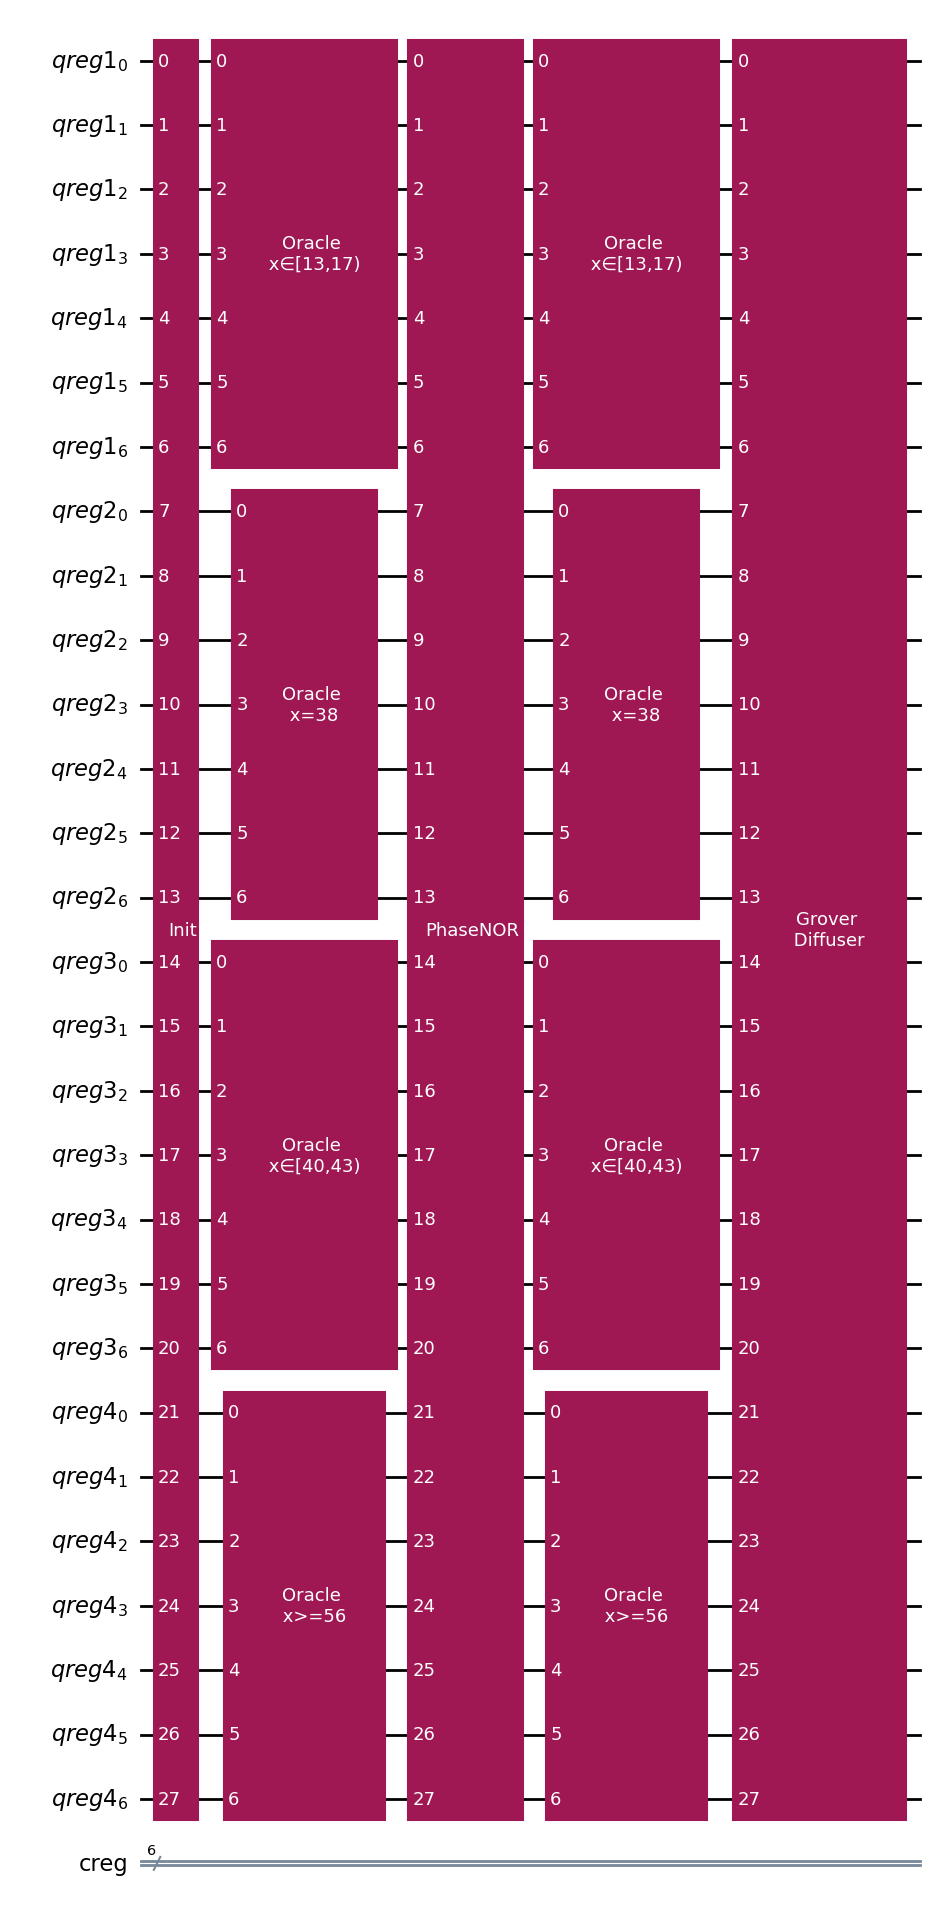

In [11]:
qubits = 7 # Number of qubits in each register, including the ancilla
m = 4 # Number of clauses (number of registers)
k = 1 # Number of Grover iterations

# List of oracles implemented as constraints
# Beware that this implementation is manual, so the number of oracles and
# registers must add up
oracles = [None] * m
oracles[0] = (oracle_interval(13, 17, qubits-1), 0)
oracles[1] = (oracle_eq(38, qubits-1), 1)
oracles[2] = (oracle_interval(40, 43, qubits-1), 2)
oracles[3] = (oracle_greatereq(56, qubits-1), 3)
# This case solves the formula in DNF:
#  F = [(x > 12) ∧ (x < 17)] ∨ (x = 38) ∨ [(x > 39) ∧ (x < 43)] ∨ (x > 55)
#                                                                 (mod 64)

q_regs = [QuantumRegister(qubits, f'qreg{j+1}') for j in range(m)]
cr = ClassicalRegister(qubits-1, 'creg')
main_circuit = QuantumCircuit(*q_regs, cr)
print('Quantum registers, classical register, and quantum circuit initialized.')

init(main_circuit, q_regs, qubits)
grover_iteration(main_circuit, q_regs, oracles, qubits, k)

# Directory where circuits and histograms are stored
project_root = Path.cwd().parent
results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

circuit_path = results_dir / "circuit_SMT_DNF_mod{}.png".format(2**(qubits-1))
main_circuit.draw('mpl', fold=-1, filename=str(circuit_path))

## Medición, Simulación y Análisis de Resultados

In [18]:
def measurement(main_circuit: QuantumCircuit, q_regs: list,
                cr: ClassicalRegister, qubits: int, shots: int):
    """
    Performs the measurement on the primary quantum register, simulates the
    circuit, and plots the measurement outcomes. The keys in the output
    dictionary are inverted to convert from Qiskit's Little-Endian to standard
    Big-Endian notation.

    Args:
        main_circuit (QuantumCircuit): The Qiskit QuantumCircuit object to be
                                       measured.
        q_regs (list): A list of QuantumRegister objects.
        cr (ClassicalRegister): The ClassicalRegister to store the outcomes.
        qubits (int): The total number of qubits in each register, without the
                      ancilla qubit.
        shots (int): The number of times the circuit is to be run.

    Returns:
        None. Prints the outcomes and displays a bar plot.
    """
    # Measure only first regsiter qubits
    for i in range(qubits):
        main_circuit.measure(q_regs[0][i], cr[i])

    # Initialize the simulator and transpile the circuit
    simulator = AerSimulator()
    compiled_circuit = transpile(main_circuit, simulator)

    # Execute the simulation
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts(compiled_circuit)

    # Invert keys for standard notation (MSB at index 0)
    inverted_counts = {key[::-1]: value for key, value in counts.items()}

    # Sort by decimal value of the bitstring
    sorted_items = sorted(inverted_counts.items(), key=lambda kv: int(kv[0], 2))
    # Format: 010₂ = 2, in ascending decimal order
    formatted_counts = {f'{k}₂ = {int(k, 2)}': v for k, v in sorted_items}
    print('Results:')
    print(formatted_counts)

    print('Simulation completed. Measurement outcomes with inverted keys to ' +
          'maintain notation.')

    # Histogram for outcome results
    outcome_labels = list(formatted_counts.keys())
    outcome_values = list(formatted_counts.values())

    plt.figure(figsize=(10, 6))
    sns.barplot(x=outcome_labels, y=outcome_values)
    plt.xlabel('Measurement Outcome')
    plt.ylabel('Counts')
    plt.title('SMT Modular Arithmetic DNF (mod{})'.format(2**qubits))
    plt.xticks(rotation=45, ha='center')
    plt.tight_layout()

    # Figure stored in results directory
    graph_path = results_dir / "histogram_SMT_DNF_mod{}.png".format(2**qubits)
    plt.savefig(graph_path, dpi=300, bbox_inches='tight')

    plt.show()

    return None

Results:
{'001101₂ = 13': 65, '001110₂ = 14': 59, '001111₂ = 15': 47, '010000₂ = 16': 81, '100110₂ = 38': 64, '101000₂ = 40': 64, '101001₂ = 41': 53, '101010₂ = 42': 68, '111000₂ = 56': 68, '111001₂ = 57': 63, '111010₂ = 58': 70, '111011₂ = 59': 78, '111100₂ = 60': 50, '111101₂ = 61': 78, '111110₂ = 62': 53, '111111₂ = 63': 63}
Simulation completed. Measurement outcomes with inverted keys to maintain notation.


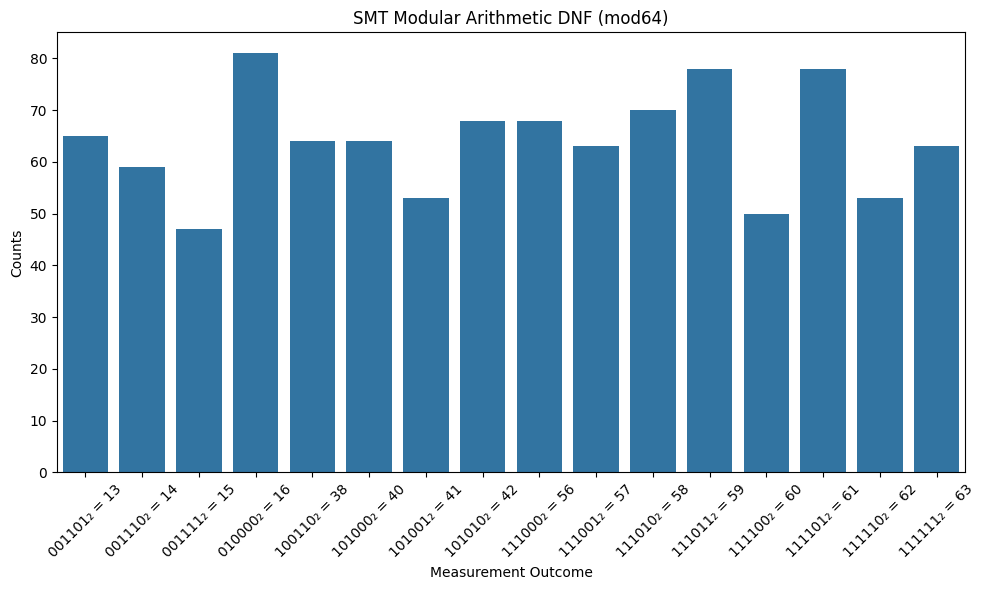

In [19]:
shots=1024
measurement(main_circuit, q_regs, cr, qubits-1, shots)

Como se observa en el histograma, las amplitudes de probabilidad han sido exitosamente amplificadas para los estados $\{13, 14, 15, 16, 38, 40, 41, 42, 56, 57, 58, 59, 60, 61, 62, 63\}$, demostrando que nuestro circuito cuántico modular ha resuelto satisfactoriamente la fórmula planteada.